In [1]:
%pip install scanpy anndata scikit-misc transformers numba rpy2 gdown

In [2]:
import os
import scipy
import anndata
import sklearn
import torch
import random
import numpy as np
import scanpy as sc
import pandas as pd
from typing import Optional
import scipy.sparse as sp
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module
from torch.backends import cudnn
from scipy.sparse import coo_matrix
from scipy.sparse import issparse
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import kneighbors_graph
from sklearn.utils import sparsefuncs
import numba
from tqdm import tqdm

def init_weights(*params):
    """Initialize weights with Xavier uniform distribution."""
    for param in params:
        torch.nn.init.xavier_uniform_(param)

def fix_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

def construct_neighbor_graph(adata_omics1, adata_omics2, datatype='SPOTS', n_neighbors=3):
    """Construct spatial and feature neighbor graphs."""
    if datatype in ['Stereo-CITE-seq', 'Spatial-epigenome-transcriptome']:
        n_neighbors = 6

    cell_position_omics1 = adata_omics1.obsm['spatial']
    adata_omics1.uns['adj_spatial'] = construct_graph_by_coordinate(cell_position_omics1, n_neighbors=n_neighbors)

    cell_position_omics2 = adata_omics2.obsm['spatial']
    adata_omics2.uns['adj_spatial'] = construct_graph_by_coordinate(cell_position_omics2, n_neighbors=n_neighbors)

    feature_graph_omics1, feature_graph_omics2 = construct_graph_by_feature(adata_omics1, adata_omics2)
    adata_omics1.obsm['adj_feature'], adata_omics2.obsm['adj_feature'] = feature_graph_omics1, feature_graph_omics2

    data = {'adata_omics1': adata_omics1, 'adata_omics2': adata_omics2}
    return data

def pca(adata, use_reps=None, n_comps=10):
    from sklearn.decomposition import PCA
    from scipy.sparse import csc_matrix, csr_matrix
    pca_model = PCA(n_components=n_comps)
    if use_reps is not None:
        feat_pca = pca_model.fit_transform(adata.obsm[use_reps])
    else:
        if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
            feat_pca = pca_model.fit_transform(adata.X.toarray())
        else:
            feat_pca = pca_model.fit_transform(adata.X)
    return feat_pca

def clr_normalize_each_cell(adata, inplace=True):
    def seurat_clr(x):
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x)) if len(x) > 0 else 1.0
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()
    adata.X = np.apply_along_axis(
        seurat_clr, 1, (adata.X.toarray() if scipy.sparse.issparse(adata.X) else np.array(adata.X))
    )
    return adata

def construct_graph_by_feature(adata_omics1, adata_omics2, k=20, mode="connectivity", metric="correlation", include_self=False):
    feature_graph_omics1 = kneighbors_graph(adata_omics1.obsm['feat'], k, mode=mode, metric=metric, include_self=include_self)
    feature_graph_omics2 = kneighbors_graph(adata_omics2.obsm['feat'], k, mode=mode, metric=metric, include_self=include_self)
    return feature_graph_omics1, feature_graph_omics2

def construct_graph_by_coordinate(cell_position, n_neighbors=3):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(cell_position)
    _, indices = nbrs.kneighbors(cell_position)
    x = indices[:, 0].repeat(n_neighbors)
    y = indices[:, 1:].flatten()
    adj = pd.DataFrame({'x': x, 'y': y, 'value': np.ones(x.size)})
    return adj

def transform_adjacent_matrix(adjacent):
    n_spot = adjacent['x'].max() + 1
    adj = coo_matrix((adjacent['value'], (adjacent['x'], adjacent['y'])), shape=(n_spot, n_spot))
    return adj

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def preprocess_graph(adj):
    adj = sp.coo_matrix(adj)
    adj_ = adj + sp.eye(adj.shape[0])
    rowsum = np.array(adj_.sum(1))
    degree_mat_inv_sqrt = sp.diags(np.power(rowsum, -0.5).flatten())
    adj_normalized = adj_.dot(degree_mat_inv_sqrt).transpose().dot(degree_mat_inv_sqrt).tocoo()
    return sparse_mx_to_torch_sparse_tensor(adj_normalized)

def adjacent_matrix_preprocessing(adata_omics1, adata_omics2, adj_emb):
    def _process_adj(adj):
        adj = adj.toarray() + adj.toarray().T
        adj = np.where(adj > 1, 1, adj)
        return preprocess_graph(adj)

    adj_spatial_omics1 = _process_adj(transform_adjacent_matrix(adata_omics1.uns['adj_spatial']))
    adj_spatial_omics2 = _process_adj(transform_adjacent_matrix(adata_omics2.uns['adj_spatial']))
    adj_emb = _process_adj(adj_emb)

    def _process_feature_adj(adj):
        adj = adj + adj.T
        return preprocess_graph(np.where(adj > 1, 1, adj))

    adj_feature_omics1 = _process_feature_adj(torch.FloatTensor(adata_omics1.obsm['adj_feature'].copy().toarray()))
    adj_feature_omics2 = _process_feature_adj(torch.FloatTensor(adata_omics2.obsm['adj_feature'].copy().toarray()))

    return {
        'adj_spatial_omics1': adj_spatial_omics1,
        'adj_spatial_omics2': adj_spatial_omics2,
        'adj_feature_omics1': adj_feature_omics1,
        'adj_feature_omics2': adj_feature_omics2,
        'adj_emb': adj_emb
    }

def lsi(adata: anndata.AnnData, n_components: int = 20, use_highly_variable: Optional[bool] = None, **kwargs):
    if use_highly_variable is None:
        use_highly_variable = "highly_variable" in adata.var
    adata_use = adata[:, adata.var["highly_variable"]] if use_highly_variable else adata
    X = tfidf(adata_use.X)
    X_norm = sklearn.preprocessing.Normalizer(norm="l1").fit_transform(X)
    X_norm = np.log1p(X_norm * 1e4)
    X_lsi = sklearn.utils.extmath.randomized_svd(X_norm, n_components, **kwargs)[0]
    X_lsi -= X_lsi.mean(axis=1, keepdims=True)
    X_lsi /= X_lsi.std(axis=1, ddof=1, keepdims=True)
    adata.obsm["X_lsi"] = X_lsi[:, 1:]

def tfidf(X):
    idf = X.shape[0] / X.sum(axis=0)
    if scipy.sparse.issparse(X):
        tf = X.multiply(1 / X.sum(axis=1))
        return tf.multiply(idf)
    else:
        tf = X / X.sum(axis=1, keepdims=True)
        return tf * idf

# ====== spaLLM Model Architecture Components ======

class DeepEncoder(Module):
    """Modality-specific GNN encoder."""
    def __init__(self, in_feat, out_feat, dropout=0.0, act=F.relu):
        super().__init__()
        self.dropout = dropout
        self.act = act
        self.hidden_dim = out_feat * 2

        self.weights = torch.nn.ParameterList([
            Parameter(torch.FloatTensor(in_feat, self.hidden_dim)),
            Parameter(torch.FloatTensor(self.hidden_dim, self.hidden_dim)),
            Parameter(torch.FloatTensor(self.hidden_dim, out_feat))
        ])
        init_weights(*self.weights)

    def forward(self, feat, adj):
        x = self._apply_layer(feat, adj, self.weights[0])
        x = self._apply_layer(x, adj, self.weights[1])
        x = torch.spmm(adj, torch.mm(x, self.weights[2]))
        return x

    def _apply_layer(self, x, adj, weight):
        x = torch.spmm(adj, torch.mm(x, weight))
        x = self.act(x)
        return F.dropout(x, self.dropout, training=self.training)

class CellEmbedding(Module):
    """Modality-specific cell embedding encoder/decoder."""
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.weight = Parameter(torch.FloatTensor(in_feat, out_feat))
        init_weights(self.weight)

    def forward(self, feat, adj):
        return torch.spmm(adj, torch.mm(feat, self.weight))

class AttentionLayer(Module):
    """Generic Multi-Input Attention Layer."""
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.w_omega = Parameter(torch.FloatTensor(in_feat, out_feat))
        self.u_omega = Parameter(torch.FloatTensor(out_feat, 1))
        init_weights(self.w_omega, self.u_omega)

    def forward(self, *embeddings):
        emb_stack = torch.cat([torch.unsqueeze(emb, dim=1) for emb in embeddings], dim=1)
        v = torch.tanh(torch.matmul(emb_stack, self.w_omega))
        vu = torch.matmul(v, self.u_omega)
        alpha = F.softmax(vu.squeeze(-1) + 1e-6, dim=1)
        emb_combined = torch.matmul(emb_stack.transpose(1, 2), alpha.unsqueeze(-1)).squeeze(-1)
        return emb_combined, alpha

class EncodingNetwork(Module):
    """Encoding network with modality-specific encoders, decoders, and attention layers."""
    def __init__(self, dim_in_omics1, dim_out_omics1, dim_in_omics2, dim_out_omics2):
        super().__init__()
        self.encoder_embedding = CellEmbedding(512, 64)
        self.decoder_embedding = CellEmbedding(64, 512)

        self.encoder_omics1 = DeepEncoder(dim_in_omics1, dim_out_omics1)
        self.decoder_omics1 = DeepEncoder(dim_out_omics1, dim_in_omics1)
        self.encoder_omics2 = DeepEncoder(dim_in_omics2, dim_out_omics2)
        self.decoder_omics2 = DeepEncoder(dim_out_omics2, dim_in_omics2)

        self.atten_feature1 = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_feature2 = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_feature = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_omics2 = AttentionLayer(dim_out_omics2, dim_out_omics2)
        self.atten_cross = AttentionLayer(dim_out_omics1, dim_out_omics2)

    def forward(self, f_omics1, f_omics2, adj_spa1, adj_fea1, adj_spa2, adj_fea2, cell_emb, adj_emb):
        emb_spa = self.encoder_embedding(cell_emb, adj_spa1)
        emb_fea = self.encoder_embedding(cell_emb, adj_emb)

        emb_latent_spa1 = self.encoder_omics1(f_omics1, adj_spa1)
        emb_latent_spa2 = self.encoder_omics2(f_omics2, adj_spa2)
        emb_latent_fea1 = self.encoder_omics1(f_omics1, adj_fea1)
        emb_latent_fea2 = self.encoder_omics2(f_omics2, adj_fea2)

        emb_att1, alpha_att1 = self.atten_feature1(emb_spa, emb_latent_spa1)
        emb_att2, alpha_att2 = self.atten_feature2(emb_fea, emb_latent_fea1)
        emb_latent_omics1, alpha_att_omics1 = self.atten_feature(emb_att1, emb_att2)
        emb_latent_omics2, alpha_omics2 = self.atten_omics2(emb_latent_spa2, emb_latent_fea2)

        emb_latent_combined, alpha = self.atten_cross(emb_latent_omics1, emb_latent_omics2)

        emb_recon1 = self.decoder_omics1(emb_latent_combined, adj_spa1)
        emb_recon2 = self.decoder_omics2(emb_latent_combined, adj_spa2)
        emb_recon_spa = self.decoder_embedding(emb_spa, adj_spa1)
        emb_recon_fea = self.decoder_embedding(emb_fea, adj_emb)

        emb_cross1 = self.encoder_omics2(self.decoder_omics2(emb_latent_omics1, adj_spa2), adj_spa2)
        emb_cross2 = self.encoder_omics1(self.decoder_omics1(emb_latent_omics2, adj_spa1), adj_spa1)

        return {
            'emb_latent_omics1': emb_latent_omics1, 'emb_latent_omics2': emb_latent_omics2,
            'emb_latent_combined': emb_latent_combined, 'emb_recon_omics1': emb_recon1, 'emb_recon_omics2': emb_recon2,
            'emb_cross1': emb_cross1, 'emb_cross2': emb_cross2,
            'alpha_att1': alpha_att1, 'alpha_att2': alpha_att2, 'alpha_omics1': alpha_att_omics1,
            'alpha_omics2': alpha_omics2, 'alpha': alpha, 'emb_recon_spa': emb_recon_spa,
            'emb_recon_fea': emb_recon_fea
        }

def add_gaussian_noise(matrix, mean=0.0, std=0.001):
    noise = torch.normal(mean=mean, std=std, size=matrix.size()).to(matrix.device)
    return matrix + noise

class Train_spaLLM:
    def __init__(self, data, embedding, datatype='10x', device=torch.device('cpu'),
                 epochval=None, random_seed=2024, learning_rate=0.0001, weight_decay=0.0, epochs=600,
                 dim_input=3000, dim_output=64, weight_factors=None, attention_type='local'):
        self.device = device
        self.data = data.copy()
        if isinstance(embedding, np.ndarray):
            self.embedding = torch.FloatTensor(embedding).to(device)
        else:
            self.embedding = embedding.to(device)
        self.datatype = datatype
        self.random_seed = random_seed
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.dim_input = dim_input
        self.dim_output = dim_output
        self.weight_factors = weight_factors or [5, 5, 1, 10, 10, 10]

        self._init_adj_and_features()
        self.loss_history = []
        self._adjust_hyperparameters()
        if epochval is not None:
            self.epochs = epochval

    def _init_adj_and_features(self):
        adj = adjacent_matrix_preprocessing(self.data['adata_omics1'], self.data['adata_omics2'], self.data['adj_emb'])
        self.adj_spatial_omics1 = adj['adj_spatial_omics1'].to(self.device)
        self.adj_spatial_omics2 = adj['adj_spatial_omics2'].to(self.device)
        self.adj_feature_omics1 = adj['adj_feature_omics1'].to(self.device)
        self.adj_feature_omics2 = adj['adj_feature_omics2'].to(self.device)
        self.adj_emb = adj['adj_emb'].to(self.device)

        self.features_omics1 = torch.FloatTensor(self.data['adata_omics1'].obsm['feat']).to(self.device)
        self.features_omics2 = torch.FloatTensor(self.data['adata_omics2'].obsm['feat']).to(self.device)
        self.dim_input1, self.dim_input2 = self.features_omics1.shape[1], self.features_omics2.shape[1]

    def _adjust_hyperparameters(self):
        if self.datatype == 'SPOTS':
            self.epochs, self.weight_factors = 600, [1, 5, 1, 1, 5, 5]
        elif self.datatype == '10x' or self.datatype == 'Stereo-CITE-seq':
            self.epochs, self.weight_factors = 200, [5, 5, 1, 10, 10, 10]
        elif self.datatype == 'Spatial-epigenome-transcriptome':
            self.epochs, self.weight_factors = 1600, [1, 5, 1, 1, 10, 10]

    def _add_noise(self):
        features_omics1_noisy = add_gaussian_noise(self.features_omics1, mean=0, std=0.1)
        embedding_noisy = add_gaussian_noise(self.embedding, mean=0, std=0.01)
        return features_omics1_noisy, embedding_noisy

    def _calculate_losses(self, results):
        loss_recon_omics1 = F.mse_loss(self.features_omics1, results['emb_recon_omics1'])
        loss_recon_omics2 = F.mse_loss(self.features_omics2, results['emb_recon_omics2'])
        loss_rec_es = F.mse_loss(self.embedding, results['emb_recon_spa'])
        loss_rec_ef = F.mse_loss(self.embedding, results['emb_recon_fea'])
        loss_corr_omics1 = F.mse_loss(results['emb_latent_omics1'], results['emb_cross1'])
        loss_corr_omics2 = F.mse_loss(results['emb_latent_omics2'], results['emb_cross2'])

        loss = (self.weight_factors[0] * loss_recon_omics1 +
                self.weight_factors[1] * loss_recon_omics2 +
                self.weight_factors[2] * loss_corr_omics1 +
                self.weight_factors[3] * loss_corr_omics2 +
                self.weight_factors[4] * loss_rec_es +
                self.weight_factors[5] * loss_rec_ef)
        return loss

    def train(self, epochs=None):
        epochs = epochs or self.epochs
        self.model = EncodingNetwork(self.dim_input1, self.dim_output, self.dim_input2, self.dim_output).to(self.device)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        for epoch in tqdm(range(epochs)):
            optimizer.zero_grad()
            if random.random() < 0.5:
                features_omics1, embedding = self._add_noise()
            else:
                features_omics1, embedding = self.features_omics1, self.embedding

            results = self.model(features_omics1, self.features_omics2, self.adj_spatial_omics1,
                                 self.adj_feature_omics1,
                                 self.adj_spatial_omics2, self.adj_feature_omics2, embedding, self.adj_emb)
            loss = self._calculate_losses(results)
            loss.backward()
            optimizer.step()
            self.loss_history.append(loss.item())

        print(f"Model training finished! Final Loss: {loss.item():.4f}\n")
        return self._evaluate_model()

    def _evaluate_model(self):
        self.model.eval()
        with torch.no_grad():
            results = self.model(self.features_omics1, self.features_omics2, self.adj_spatial_omics1,
                                 self.adj_feature_omics1, self.adj_spatial_omics2, self.adj_feature_omics2,
                                 self.embedding, self.adj_emb)

        return {
            'emb_latent_omics1': F.normalize(results['emb_latent_omics1'], p=2).cpu().numpy(),
            'emb_latent_omics2': F.normalize(results['emb_latent_omics2'], p=2).cpu().numpy(),
            'SpatialGlue': F.normalize(results['emb_latent_combined'], p=2).cpu().numpy(),
            'alpha_omics1': results['alpha_omics1'].cpu().numpy(),
            'alpha_omics2': results['alpha_omics2'].cpu().numpy(),
            'alpha': results['alpha'].cpu().numpy(),
            'alpha_att1': results['alpha_att1'].cpu().numpy(),
            'alpha_att2': results['alpha_att2'].cpu().numpy()
        }

Train_SpatialGlue = Train_spaLLM

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2020):
    import rpy2.robjects as robjects
    from rpy2.robjects import pandas2ri, default_converter
    from rpy2.robjects.conversion import localconverter

    np.random.seed(random_seed)
    robjects.r.library("mclust")
    r_random_seed = robjects.r["set.seed"]
    r_random_seed(random_seed)

    rmclust = robjects.r["Mclust"]
    X = np.array(adata.obsm[used_obsm], dtype=np.float64)
    print("Input shape:", X.shape)

    df = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
    subset_size = min(300, X.shape[0])
    subset_indices = robjects.IntVector(list(np.random.choice(range(1, X.shape[0] + 1), subset_size, replace=False)))
    init_list = robjects.ListVector({'subset': subset_indices})

    with localconverter(default_converter + pandas2ri.converter):
        res = rmclust(df, G=num_cluster, modelNames=modelNames, initialization=init_list)

    mclust_res = np.array(res['classification'])
    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int').astype('str').astype('category')
    return adata

def clustering(adata, n_clusters=7, key='emb', add_key='SpatialGlue', method='mclust', start=0.1, end=3.0, increment=0.01, use_pca=False, n_comps=20):
    if use_pca:
        adata.obsm[key + '_pca'] = pca(adata, use_reps=key, n_comps=n_comps)

    if method == 'mclust':
        used = key + '_pca' if use_pca else key
        adata = mclust_R(adata, used_obsm=used, num_cluster=n_clusters)
        adata.obs[add_key] = adata.obs['mclust']
    elif method in ['leiden', 'louvain']:
        used = key + '_pca' if use_pca else key
        res = search_res(adata, n_clusters, use_rep=used, method=method, start=start, end=end, increment=increment)
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            adata.obs[add_key] = adata.obs['leiden']
        else:
            sc.tl.louvain(adata, random_state=0, resolution=res)
            adata.obs[add_key] = adata.obs['louvain']

def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
        elif method == 'louvain':
            sc.tl.louvain(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique())
        if count_unique == n_clusters:
            label = 1
            break
    assert label == 1, "Resolution is not found. Please try bigger range or smaller step!"
    return res

def sf_normalize(X):
    X = X.copy()
    counts = np.array(X.sum(axis=1))
    counts += counts == 0.
    scaling_factor = 10000. / counts
    if issparse(X):
        sparsefuncs.inplace_row_scale(X, scaling_factor)
    else:
        np.multiply(X, scaling_factor.reshape((-1, 1)), out=X)
    return X

@numba.jit(nopython=True, nogil=True)
def _sub_tokenize_data(x, max_seq_len=-1, aux_tokens=30):
    scores_final = np.empty((x.shape[0], max_seq_len if max_seq_len > 0 else x.shape[1]))
    for i, cell in enumerate(x):
        nonzero_mask = np.nonzero(cell)[0]
        sorted_indices = nonzero_mask[np.argsort(-cell[nonzero_mask])][:max_seq_len]
        sorted_indices = sorted_indices + aux_tokens
        if max_seq_len:
            scores = np.zeros(max_seq_len, dtype=np.int32)
        else:
            scores = np.zeros_like(cell, dtype=np.int32)
        scores[:len(sorted_indices)] = sorted_indices.astype(np.int32)
        scores_final[i, :] = scores
    return scores_final

def tokenize_for_nicheformer(X_raw, max_seq_len=1500, aux_tokens=30):
    X = X_raw.copy()
    if issparse(X):
        X = X.toarray()
    X = np.nan_to_num(X)
    X = sf_normalize(X)
    median_counts_per_gene = np.median(X, axis=0)
    median_counts_per_gene += median_counts_per_gene == 0
    X = X / median_counts_per_gene.reshape((1, -1))
    tokens = _sub_tokenize_data(X, max_seq_len, aux_tokens).astype(np.int32)
    return tokens

def extract_nicheformer_embeddings(model, tokens_np, batch_size=16, layer=-1):
    model.eval()
    all_embs = []
    n_cells = tokens_np.shape[0]
    padding_token = 1

    with torch.no_grad():
        for start in range(0, n_cells, batch_size):
            end = min(start + batch_size, n_cells)
            batch_tokens = torch.LongTensor(tokens_np[start:end]).to(next(model.parameters()).device)
            batch_tokens = torch.where(batch_tokens == 0, torch.tensor(padding_token, device=batch_tokens.device), batch_tokens)
            attention_mask = (batch_tokens == padding_token).bool()

            try:
                outputs = model(input_ids=batch_tokens, attention_mask=attention_mask)
                if hasattr(outputs, 'last_hidden_state'):
                    hidden = outputs.last_hidden_state
                elif hasattr(outputs, 'hidden_states') and outputs.hidden_states is not None:
                    hidden = outputs.hidden_states[layer]
                elif isinstance(outputs, dict):
                    hidden = outputs.get('last_hidden_state', outputs.get('logits', list(outputs.values())[0]))
                else:
                    hidden = outputs[0] if isinstance(outputs, tuple) else outputs
            except TypeError:
                token_embedding = model.embeddings(batch_tokens)
                if hasattr(model, 'positional_embedding'):
                    pos = torch.arange(0, batch_tokens.shape[1], dtype=torch.long, device=batch_tokens.device)
                    pos_embedding = model.positional_embedding(pos)
                    embeddings = model.dropout(token_embedding + pos_embedding) if hasattr(model, 'dropout') else (token_embedding + pos_embedding)
                else:
                    embeddings = token_embedding
                if hasattr(model.encoder, 'layers'):
                    layer_idx = len(model.encoder.layers) + layer if layer < 0 else layer
                    for i in range(layer_idx + 1):
                        embeddings = model.encoder.layers[i](embeddings, src_key_padding_mask=attention_mask, is_causal=False)
                    hidden = embeddings

            hidden = hidden[:, 3:, :]
            hidden = hidden.mean(dim=1)
            all_embs.append(hidden.cpu())
        del batch_tokens, outputs, hidden
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(all_embs, dim=0)



# Data Load
## Please Give input for Dataset number [0 - 5];

In [3]:
DATASET = 0

choices = [
    ("10x_human_lymph_node_A1",
     "https://drive.google.com/drive/folders/10z1N4MwW8Y49o8GlkYGBKVx1N7fiMuyC"),
    ("10x_human_lymph_node_D1",
     "https://drive.google.com/drive/folders/1-g_Ca2XMaMXF-MisuVY-wobWDX86O6zz"),
    ("Mouse_Brain_E11_S1",
     "https://drive.google.com/drive/folders/1zRwDJrYnks0LRzlAVRqPU7jE_OcStgPo"),
    ("Mouse_Brain_E13_S1",
     "https://drive.google.com/drive/folders/1GOufwIRjjfcd9Bi2GKtebzKoPCg2jVud"),
    ("Mouse_Brain_E15_S1",
     "https://drive.google.com/drive/folders/1rHkTL5OF5qPsEERypRGMS51SjUQ69tdD"),
    ("Mouse_Brain_E18_S1",
     "https://drive.google.com/drive/folders/1Xj1LNIAY93biS6JIMKNRODn5GvtCKADB"),
]

dataset_name, folder_url = choices[DATASET]

import scanpy as sc
import pandas as pd

# Create data directory
!mkdir -p data

# Download only the selected folder
!gdown --folder "{folder_url}" --output data

!ls data


Retrieving folder contents
Processing file 1p1EllZRpgEEOEP6T5zWnv3kvJmEgJXLm adata_ADT.h5ad
Processing file 19kW58NNMJXSPDBFCYP6RfrgSECyJhLbL adata_RNA.h5ad
Processing file 1SlFY5iiFyamiqa6SfmDKHb-zy512ygMA annotation.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1p1EllZRpgEEOEP6T5zWnv3kvJmEgJXLm
To: /content/data/adata_ADT.h5ad
100% 1.14M/1.14M [00:00<00:00, 35.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=19kW58NNMJXSPDBFCYP6RfrgSECyJhLbL
To: /content/data/adata_RNA.h5ad
100% 56.6M/56.6M [00:00<00:00, 108MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SlFY5iiFyamiqa6SfmDKHb-zy512ygMA
To: /content/data/annotation.csv
100% 114k/114k [00:00<00:00, 104MB/s]
Download completed
adata_ADT.h5ad	adata_ATAC.h5ad  adata_RNA.h5ad  anno.csv  annotation.csv


In [4]:



base = f"data/"

rna_path = os.path.join(base, "adata_RNA.h5ad")

# Human datasets have ADT; Mouse datasets have ATAC
if dataset_name.startswith("10x"):
    other_path = os.path.join(base, "adata_ADT.h5ad")
    annotation_path = os.path.join(base, "annotation.csv")
    anno_df = pd.read_csv(annotation_path, index_col=0)
    gt_column = "manual-anno"
    data_type = '10x'

else:
    other_path = os.path.join(base, "adata_ATAC.h5ad")
    annotation_path = os.path.join(base, "anno.csv")
    anno_df = pd.read_csv(annotation_path, index_col=0)
    gt_column = "cluster"
    data_type = 'Spatial-epigenome-transcriptome'

adata_omics1 = sc.read_h5ad(rna_path)
adata_omics2 = sc.read_h5ad(other_path)

print("Data loaded successfully from the separate data folder!")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

print("variable named unique")


# 2. Add the 'manual-anno' column to the 'obs' dataframe of both AnnData objects
# Pandas will automatically align the indices (Barcodes)
adata_omics1.obs['ground_truth'] = anno_df[gt_column]
adata_omics2.obs['ground_truth'] = anno_df[gt_column]

print("Ground truth added successfully!")

print(adata_omics1)
print(adata_omics2)


random_seed = 2022
fix_seed(random_seed)


Data loaded successfully from the separate data folder!
variable named unique
Ground truth added successfully!
AnnData object with n_obs × n_vars = 3484 × 18085
    obs: 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: None (.X)
AnnData object with n_obs × n_vars = 3484 × 31
    obs: 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: None (.X)


/tmp/ipykernel_4501/3800908579.py:20: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata_omics1 = sc.read_h5ad(rna_path)
/tmp/ipykernel_4501/3800908579.py:21: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata_omics2 = sc.read_h5ad(other_path)


# Preprocessing

In [5]:
# =======================
# RNA preprocessing (NicheFormer)
# =======================

sc.pp.filter_genes(adata_omics1, min_cells=10)

# Only for ATAC datasets
if not dataset_name.startswith('10x'):
    sc.pp.filter_cells(adata_omics1, min_genes=200)

# Annotation alignment fix
common_cells = adata_omics1.obs_names.intersection(adata_omics2.obs_names)
adata_omics1 = adata_omics1[common_cells].copy()
adata_omics2 = adata_omics2[common_cells].copy()
anno_df = anno_df.loc[anno_df.index.isin(common_cells)].copy()
adata_omics1.obs['ground_truth'] = anno_df[gt_column]

print(f'RNA after filtering: {adata_omics1.shape}')

# ---- NicheFormer tokenization ----
rna_tokens = tokenize_for_nicheformer(adata_omics1.X, max_seq_len=1500)
print(f'RNA tokens: {rna_tokens.shape}')

RNA after filtering: (3484, 17954)
RNA tokens: (3484, 1500)


In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from transformers import AutoModel

nicheformer_model = AutoModel.from_pretrained(
    'theislab/Nicheformer',
    trust_remote_code=True
)
nicheformer_model = nicheformer_model.to(device)
nicheformer_model.eval()

print(f'Model loaded: {sum(p.numel() for p in nicheformer_model.parameters()):,} parameters')

Loading weights:   0%|          | 0/159 [00:00<?, ?it/s]

[transformers] NicheformerModel LOAD REPORT from: theislab/Nicheformer
Key                    | Status     |  | 
-----------------------+------------+--+-
classifier_head.weight | UNEXPECTED |  | 
classifier_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: 38,520,832 parameters


In [7]:
vocab_size = nicheformer_model.embeddings.num_embeddings
max_valid_token_id = vocab_size - 1

# Create a copy to avoid modifying original rna_tokens if it's used elsewhere
rna_tokens_processed = rna_tokens.copy()

# Replace out-of-bounds non-padding tokens with padding token (0).
# extract_nicheformer_embeddings converts 0 to its own padding token (1).
out_of_bounds_mask = (rna_tokens_processed >= vocab_size) & (rna_tokens_processed != 0)
rna_tokens_processed[out_of_bounds_mask] = 0

emb_rna = extract_nicheformer_embeddings(nicheformer_model, rna_tokens_processed, batch_size=16)
emb_rna = emb_rna.numpy()

if np.isnan(emb_rna).any():
    print(f"Warning: Found {np.isnan(emb_rna).sum()} NaN values in RNA embeddings. Filling with 0.")
    emb_rna = np.nan_to_num(emb_rna, nan=0.0)

print(f'RNA embeddings (NicheFormer): {emb_rna.shape}')

# Preprocess RNA for PCA features in spaLLM GNN encoder
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)
adata_rna_high = adata_omics1[:, adata_omics1.var['highly_variable']]

if dataset_name.startswith('10x'):
    n_comps_rna = adata_omics2.n_vars - 1
    print(f"Using {n_comps_rna} components for RNA PCA")
    adata_omics1.obsm['feat'] = pca(adata_rna_high, n_comps=n_comps_rna)
else:
    n_comps_rna = min(50, adata_rna_high.n_obs - 1, adata_rna_high.n_vars - 1)
    print(f"Using {n_comps_rna} components for RNA PCA")
    adata_omics1.obsm['feat'] = pca(adata_rna_high, n_comps=n_comps_rna)


RNA embeddings (NicheFormer): (3484, 512)


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Using 30 components for RNA PCA


In [8]:
# =======================
# Protein or ATAC preprocessing
# =======================

if dataset_name.startswith('10x'):
    # ---------- Protein ----------
    adata_omics2 = clr_normalize_each_cell(adata_omics2)
    sc.pp.scale(adata_omics2)

    adata_omics2.obsm['feat'] = pca(
        adata_omics2,
        n_comps=adata_omics2.n_vars - 1
    )
else:
    # ---------- ATAC ----------
    adata_omics2 = adata_omics2[adata_omics1.obs_names].copy()
    sc.pp.normalize_total(adata_omics2, target_sum=1e4)
    sc.pp.log1p(adata_omics2)
    sc.pp.scale(adata_omics2)
    n_comps_mod2 = min(50, adata_omics2.n_obs - 1, adata_omics2.n_vars - 1)
    print(f"Using {n_comps_mod2} components for ATAC PCA")
    adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=n_comps_mod2)

print("RNA AnnData:", adata_omics1)
print("Modality 2 AnnData:", adata_omics2)



RNA AnnData: AnnData object with n_obs × n_vars = 3484 × 17954
    obs: 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'feat'
    layers: None (.X)
Modality 2 AnnData: AnnData object with n_obs × n_vars = 3484 × 31
    obs: 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    obsm: 'spatial', 'feat'
    layers: None (.X)


# Graph construct and model run

In [9]:
print("Constructing spatial and feature neighbor graphs...")
data = construct_neighbor_graph(adata_omics1, adata_omics2, datatype=data_type)

print("Constructing NicheFormer embedding neighbor graph...")
data['adj_emb'] = kneighbors_graph(emb_rna, 20, mode="connectivity", metric="correlation", include_self=False)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Training spaLLM model using NicheFormer cell embeddings on {device}...")

model = Train_spaLLM(data, embedding=emb_rna, datatype=data_type, device=device)
output = model.train()

adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['SpatialGlue'] = output['SpatialGlue'].copy()
adata.obsm['alpha'] = output['alpha'].copy()
adata.obsm['alpha_omics1'] = output['alpha_omics1'].copy()
adata.obsm['alpha_omics2'] = output['alpha_omics2'].copy()



Constructing spatial and feature neighbor graphs...
Constructing NicheFormer embedding neighbor graph...
Training spaLLM model using NicheFormer cell embeddings on cuda:0...


/tmp/ipykernel_4501/1757568682.py:107: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(indices, values, shape)
100%|██████████| 200/200 [00:14<00:00, 13.55it/s]


Model training finished! Final Loss: 26.9558



# Clustering

In [10]:
import os

# Set R_HOME before any rpy2 imports
os.environ['R_HOME'] = '/usr/lib/R'
os.environ['PATH'] = '/usr/lib/R/bin:' + os.environ['PATH']

# Import rpy2
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, default_converter
import rpy2.robjects.conversion as cv

cv.set_conversion(default_converter + pandas2ri.converter)

# Suppress warnings
robjects.r.options(warn=-1)

# Install mclust only if it is not already installed
robjects.r("""
if (!requireNamespace("mclust", quietly = TRUE)) {
    install.packages("mclust", repos="https://cloud.r-project.org")
}
library(mclust)
""")



# we set 'mclust' as clustering tool by default. Users can also select 'leiden' and 'louvain'

# Number of unique ground-truth labels
n_ground_truth = adata_omics1.obs["ground_truth"].nunique()

print(f"Number of ground truth classes: {n_ground_truth}")

n_cluster=n_ground_truth
# n_cluster=9

tool = 'mclust' # mclust, leiden, and louvain
clustering(adata, key='SpatialGlue', add_key='SpatialGlue', n_clusters=n_cluster, method=tool, use_pca=True)


   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.3
Type 'citation("mclust")' for citing this R package in publications.



Number of ground truth classes: 10
Input shape: (3484, 20)
fitting ...
  |======================================================================| 100%


# Score generate

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    v_measure_score,
    silhouette_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

import scanpy as sc

y_true = adata.obs['ground_truth'].astype(str)
y_pred = adata.obs['SpatialGlue'].astype(str)
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
ami = adjusted_mutual_info_score(y_true, y_pred)
homogeneity = homogeneity_score(y_true, y_pred)
v_measure = v_measure_score(y_true, y_pred)

joint_feat = adata.obsm['SpatialGlue']
sil_score = silhouette_score(
    joint_feat,
    adata.obs['SpatialGlue'].astype(int)
)

print(f'Result')
print(f'Dataset: {dataset_name}')
print(f'Tool: {tool}')
print(f'Cluster size: {n_cluster}')
print()
print(f'ARI: {ari:.4f}')
print(f'NMI: {nmi:.4f}')
print(f'AMI: {ami:.4f}')
print(f'Homogeneity: {homogeneity:.4f}')
print(f'V-measure: {v_measure:.4f}')
print(f'Silhouette: {sil_score:.4f}')

Result
Dataset: 10x_human_lymph_node_A1
Tool: mclust
Cluster size: 10

ARI: 0.2624
NMI: 0.3763
AMI: 0.3723
Homogeneity: 0.4170
V-measure: 0.3763
Silhouette: 0.3176


In [12]:
sc.pp.neighbors(adata, use_rep='SpatialGlue')
sc.tl.umap(adata)

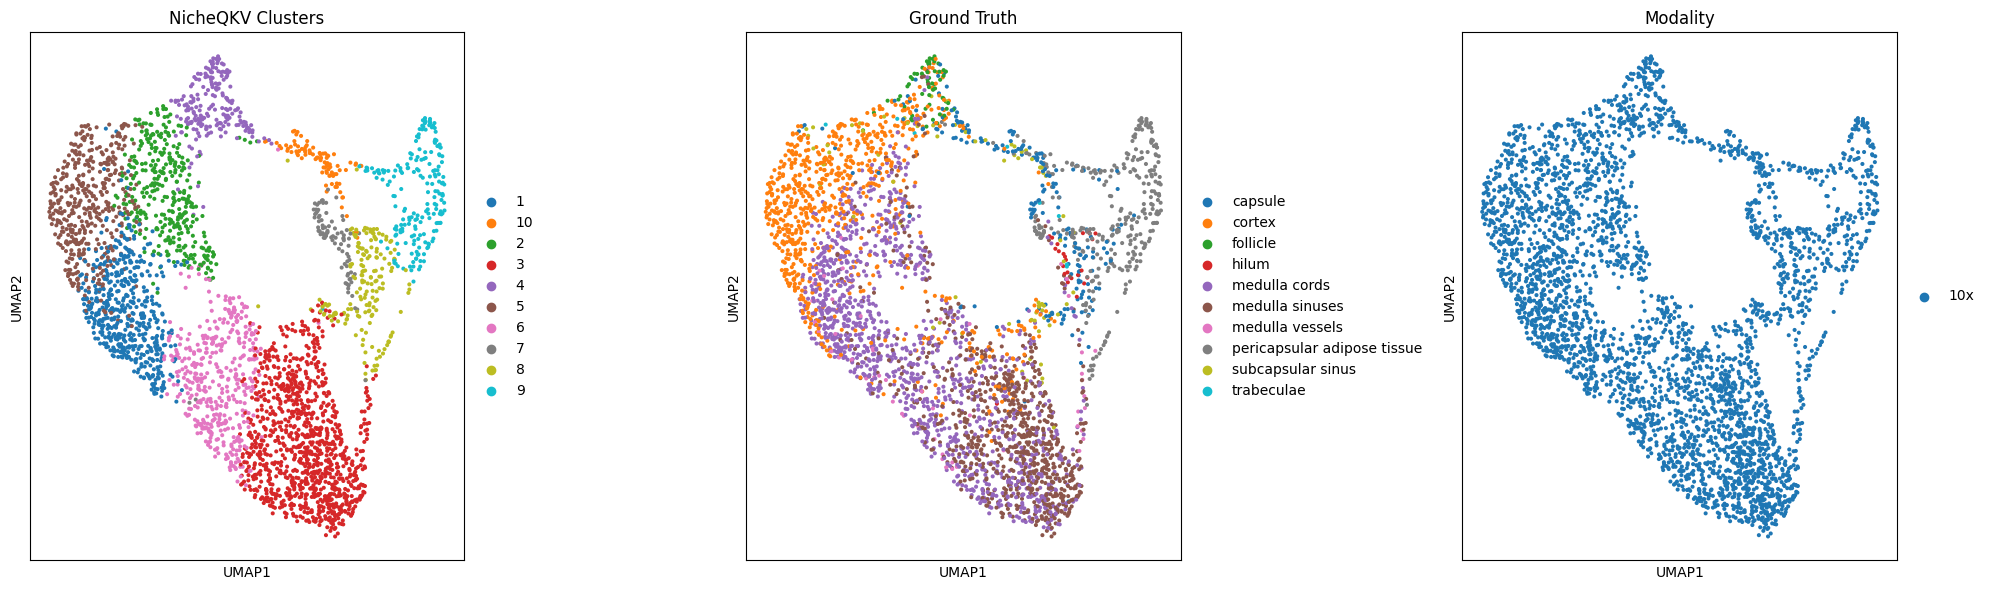

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sc.pl.umap(adata, color='mclust', ax=axes[0], show=False, title='NicheQKV Clusters')
sc.pl.umap(adata, color='ground_truth', ax=axes[1], show=False, title='Ground Truth')
adata.obs['Modality'] = data_type
sc.pl.umap(adata, color='Modality', ax=axes[2], show=False, title='Modality')
plt.tight_layout()
plt.show()